# J09 — Transfert de chaleur dans le sol

**Physique et hydrodynamique des sols** — S. J. Gumiere

*Atelier du Jour 9 : propriétés thermiques, onde amortie, schéma implicite, module Heat Transport de HYDRUS-1D*

> Version **instructeur** : code complet et résultats.

## Mise en place

Unités : SI pour les propriétés (W m$^{-1}$ K$^{-1}$, J m$^{-3}$ K$^{-1}$), puis cm et jours pour les simulations (HYDRUS : g, cm, j).
Les projets HYDRUS-1D sont dans `../../hydrus/` (lecteurs dans `../hydrus_io.py`).

In [1]:
import sys
sys.path.insert(0, "..")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import optimize, special, linalg
from hydrus_io import read_obs_node, read_nod_inf, read_tlevel

plt.rcParams.update({"figure.figsize": (7.5, 4), "axes.grid": True, "grid.alpha": 0.3})
HYD = "../../hydrus"
OM = 2 * np.pi          # pulsation journalière (rad/j)
S2J = 86400.0           # secondes par jour

## Exercice 1 — Propriétés thermiques en fonction de la teneur en eau  *(≈ 12 min)*

Conductivité thermique de Chung & Horton (1987) : $\lambda(\theta) = b_1 + b_2\theta + b_3\theta^{0,5}$ (W m$^{-1}$ K$^{-1}$), avec
sable (0,228 ; −2,406 ; 4,909), loam (0,243 ; 0,393 ; 1,534), argile (−0,197 ; −0,962 ; 2,521) — valeurs par défaut de HYDRUS-1D.
Capacité thermique volumique de de Vries : $C = \theta_n C_n + \theta_o C_o + \theta C_w$ avec $C_n = 1{,}92$, $C_o = 2{,}51$,
$C_w = 4{,}18$ MJ m$^{-3}$ K$^{-1}$ ; $\theta_n = 1 - \theta_s - \theta_o$ ($\theta_s$ = 0,43 / 0,43 / 0,38 ; $\theta_o = 0$).

1. Écrire `lam_CH(theta, sol)` et `C_vol(theta, sol)` ; tracer $\lambda(\theta)$, $C(\theta)$ et $D_T = \lambda/C$ (en cm²/j) pour les trois sols.
2. À $\theta = 0{,}6\,\theta_s$, calculer $D_T$, la profondeur d'amortissement journalière $d = \sqrt{2D_T/\omega}$ et annuelle.
3. Convertir $b_1, b_2, b_3$ (W m$^{-1}$ K$^{-1}$ → g cm j$^{-3}$ K$^{-1}$) et $C_n, C_o, C_w$ (J m$^{-3}$ K$^{-1}$ → g cm$^{-1}$ j$^{-2}$ K$^{-1}$)
   pour le loam. Démontrer les facteurs (1 W = 1 kg m² s$^{-3}$) puis comparer aux valeurs du bloc E de `J09_chaleur_sans_convection/SELECTOR.IN`
   (les lire dans le fichier).
4. Pour le loam à $h = -100$ cm ($\theta = 0{,}243$, projet HYDRUS), donner $\lambda$, $C$, $D_T$ et $d$ : ce sont les valeurs de référence de l'exercice 4.

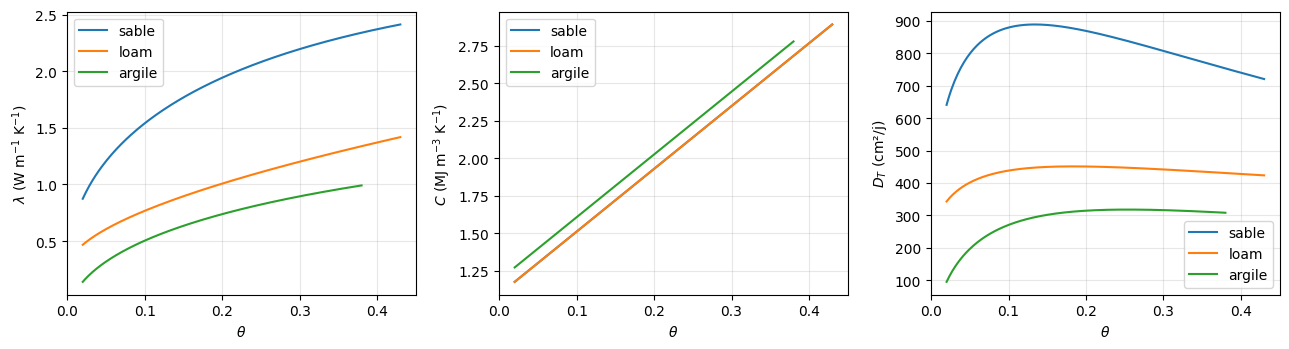

,sol,theta,lam,C_MJ,D_T_cm2_j,d_jour_cm,d_an_m
0,sable,0.258,2.101,2.173,835.320,16.306,3.115
1,loam,0.258,1.124,2.173,446.772,11.925,2.278
2,argile,0.228,0.787,2.143,317.403,10.051,1.920


facteur lambda = 6.4497e+19 ; facteur C = 7.4650e+10
loam, unités HYDRUS : b1, b2, b3 = ['1.56728e+19', '2.53474e+19', '9.89388e+19'] ; Cn, Co, Cw = ['1.43327e+17', '1.87370e+17', '3.12035e+17']
SELECTOR.IN bloc E : ['thn', 'tho', 'lambda', 'b1', 'b2', 'b3', 'Cn', 'C0', 'Cw']
                     [5.70000e-01 0.00000e+00 5.00000e+00 1.56728e+19 2.53474e+19 9.89388e+19
 1.43327e+17 1.87370e+17 3.12035e+17]
écart relatif max (b1..Cw) : 2.65e-06
loam, theta = 0.243 : lambda = 1.095 W/m/K ; C = 2.110 MJ/m³/K ; D_T = 448.2 cm²/j ; d_jour = 11.94 cm ; d_an = 2.28 m


In [2]:
CH = {"sable": (0.228, -2.406, 4.909), "loam": (0.243, 0.393, 1.534), "argile": (-0.197, -0.962, 2.521)}
THS = {"sable": 0.43, "loam": 0.43, "argile": 0.38}
Cn, Co, Cw = 1.92e6, 2.51e6, 4.18e6      # J m-3 K-1

def lam_CH(theta, sol):
    """Conductivité thermique (W m-1 K-1), Chung & Horton (1987)."""
    b1, b2, b3 = CH[sol]
    return b1 + b2 * theta + b3 * np.sqrt(theta)

def C_vol(theta, sol, theta_o=0.0):
    """Capacité thermique volumique (J m-3 K-1), de Vries (1963)."""
    return Cn * (1 - THS[sol] - theta_o) + Co * theta_o + Cw * theta

# 1. tracés
fig, ax = plt.subplots(1, 3, figsize=(13, 3.6))
for sol in CH:
    th = np.linspace(0.02, THS[sol], 200)
    lam, Cv = lam_CH(th, sol), C_vol(th, sol)
    ax[0].plot(th, lam, label=sol); ax[1].plot(th, Cv / 1e6, label=sol); ax[2].plot(th, lam / Cv * 1e4 * S2J, label=sol)
for a, lab in zip(ax, ["$\\lambda$ (W m$^{-1}$ K$^{-1}$)", "$C$ (MJ m$^{-3}$ K$^{-1}$)", "$D_T$ (cm²/j)"]):
    a.set_xlabel(r"$\theta$"); a.set_ylabel(lab); a.legend()
plt.tight_layout(); plt.show()

# 2. profondeurs d'amortissement à theta = 0.6 theta_s
rows = []
for sol in CH:
    th = 0.6 * THS[sol]
    DT = lam_CH(th, sol) / C_vol(th, sol) * 1e4 * S2J          # cm²/j
    rows.append(dict(sol=sol, theta=th, lam=lam_CH(th, sol), C_MJ=C_vol(th, sol) / 1e6, D_T_cm2_j=DT,
                     d_jour_cm=np.sqrt(2 * DT / OM), d_an_m=np.sqrt(2 * DT / (OM / 365)) / 100))
display(pd.DataFrame(rows).round(3))

# 3. conversion vers les unités HYDRUS (g, cm, j) : 1 W/m/K = 1 kg m s^-3 K^-1 ; 1 J/m³/K = 1 kg m^-1 s^-2 K^-1
f_lam = 1e3 * 1e2 * S2J ** 3          # g · cm · j^-3
f_C = 1e3 * 1e-2 * S2J ** 2           # g · cm^-1 · j^-2
print(f"facteur lambda = {f_lam:.4e} ; facteur C = {f_C:.4e}")
b_h = np.array(CH["loam"]) * f_lam; C_h = np.array([Cn, Co, Cw]) * f_C
print("loam, unités HYDRUS : b1, b2, b3 =", [f"{v:.5e}" for v in b_h], "; Cn, Co, Cw =", [f"{v:.5e}" for v in C_h])
lines = open(f"{HYD}/J09_chaleur_sans_convection/SELECTOR.IN").read().splitlines()
i = next(k for k, l in enumerate(lines) if l.strip().startswith("thn"))
sel = np.array(lines[i + 1].split(), float)
print("SELECTOR.IN bloc E :", lines[i].split()); print("                    ", sel)
print("écart relatif max (b1..Cw) :", f"{np.max(np.abs(np.concatenate([b_h, C_h]) / sel[3:9] - 1)):.2e}")

# 4. loam à theta = 0.243
th = 0.243
lam_l, C_l = lam_CH(th, "loam"), C_vol(th, "loam")
DT_l = lam_l / C_l * 1e4 * S2J
d_l = np.sqrt(2 * DT_l / OM)
print(f"loam, theta = {th} : lambda = {lam_l:.3f} W/m/K ; C = {C_l/1e6:.3f} MJ/m³/K ; D_T = {DT_l:.1f} cm²/j ; d_jour = {d_l:.2f} cm ; d_an = {d_l*np.sqrt(365)/100:.2f} m")

**Commentaire (instructeur).** La conductivité du sable est la plus sensible à $\theta$ (ponts d'eau entre gros grains), celle de l'argile la plus faible ;
$D_T$ passe par un maximum vers $\theta \approx 0{,}1$–0,2 puis décroît car $C$ continue de croître. Les facteurs $6{,}45\times10^{19}$ et
$7{,}46\times10^{10}$ reproduisent exactement les valeurs du bloc E (`1.56728e19`, `3.12035e17`, etc.) : ce ne sont que des changements d'unités.
À $\theta = 0{,}243$, $D_T = 448$ cm²/j et $d = 11{,}9$ cm : valeur à retrouver dans les simulations HYDRUS.

## Exercice 2 — Ajustement d'une onde amortie sur des températures mesurées  *(≈ 15 min)*

`data/J09_temperatures_horaires.csv` : températures horaires « mesurées » à 5, 10, 20 et 40 cm pendant 5 jours (`t_j`, `T_5cm`, … ; bruit
de capteur et dérive lente de la moyenne).

1. Tracer les quatre séries. Pour chaque profondeur, ajuster par `curve_fit` le modèle $T = T_m + a\,t + A\sin(\omega t + \varphi)$
   ($\omega = 2\pi$ rad/j connu) ; récupérer $A(z) > 0$ et $\varphi(z)$ (ramener $A$ positif et $\varphi$ continu avec `np.unwrap`).
2. Régresser $\ln A$ sur $z$ (pente $-1/d_A$) et $\varphi$ sur $z$ (pente $-1/d_\varphi$) : deux estimations de $d$, donc de
   $D_T = \omega d^2/2$. Comparer entre elles et à la valeur du loam (exercice 1).
3. Quelle est l'heure du maximum à chaque profondeur ? Vérifier que le retard croît linéairement avec $z$.
4. Refaire l'ajustement en omettant la dérive ($a = 0$) : effet sur $A$, $\varphi$ et $d$ ? Pourquoi la profondeur 40 cm est-elle la plus incertaine ?

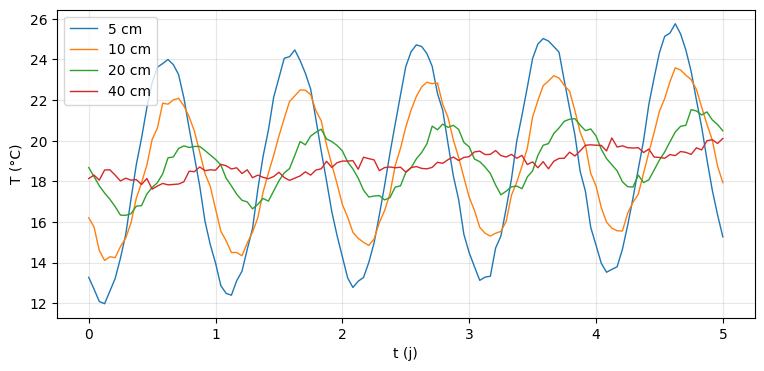

,z_cm,Tm,derive_C_j,A,phi,rmse
0,5,17.957,0.364,5.913,4.031,0.139
1,10,18.009,0.349,3.909,3.616,0.148
2,20,18.014,0.358,1.685,2.764,0.148
3,40,17.959,0.363,0.347,1.146,0.147


d (amplitude) = 12.35 cm -> D_T = 479 cm²/j ; d (phase) = 12.13 cm -> D_T = 462 cm²/j ; loam ex. 1 : d = 11.94 cm, D_T = 448 cm²/j
amplitude en surface extrapolée : A0 = 8.75 °C


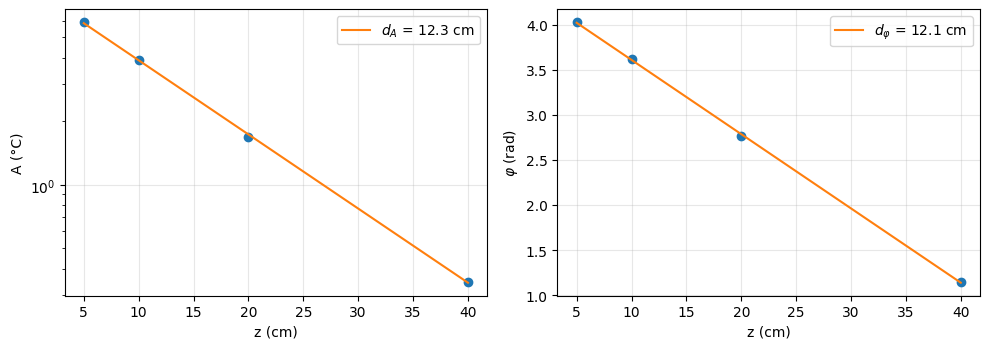

,z_cm,A,phi,t_max_h,retard_h
0,5,5.91,4.03,14.60,0.00
1,10,3.91,3.62,16.19,1.58
2,20,1.68,2.76,19.44,4.84
3,40,0.35,1.15,1.62,11.02


retard théorique (h) par rapport à 5 cm : [ 0.    1.6   4.8  11.19]
sans dérive : d_A = 11.90 cm, d_phi = 13.89 cm ; RMSE moyen 0.536 contre 0.146 °C avec dérive


In [3]:
tp = pd.read_csv("data/J09_temperatures_horaires.csv")
t = tp["t_j"].to_numpy(); zs = np.array([5, 10, 20, 40])

def modele(t, Tm, a, A, phi):
    return Tm + a * t + A * np.sin(OM * t + phi)

def ajuste(colonnes, derive=True):
    res = []
    for z in zs:
        y = tp[f"T_{z}cm"].to_numpy()
        if derive:
            p, cov = optimize.curve_fit(modele, t, y, p0=[20, 0, 5, 0])
        else:
            p, cov = optimize.curve_fit(lambda t, Tm, A, phi: modele(t, Tm, 0, A, phi), t, y, p0=[20, 5, 0])
            p = np.insert(p, 1, 0.0)
        Tm, a, A, phi = p
        if A < 0: A, phi = -A, phi + np.pi
        res.append(dict(z_cm=z, Tm=Tm, derive_C_j=a, A=A, phi=phi, rmse=np.sqrt(np.mean((modele(t, *p) - y) ** 2))))
    df = pd.DataFrame(res)
    df["phi"] = np.unwrap(df["phi"].to_numpy())
    return df

# 1. séries et ajustement
fig, ax = plt.subplots(figsize=(9, 4))
for z in zs:
    ax.plot(t, tp[f"T_{z}cm"], lw=1, label=f"{z} cm")
ax.set_xlabel("t (j)"); ax.set_ylabel("T (°C)"); ax.legend(); plt.show()
fit = ajuste(zs)
display(fit.round(3))

# 2. deux estimations de d
sA, iA = np.polyfit(zs, np.log(fit["A"]), 1)
sP, iP = np.polyfit(zs, fit["phi"], 1)
d_A, d_phi = -1 / sA, -1 / sP
DT_A, DT_phi = OM * d_A ** 2 / 2, OM * d_phi ** 2 / 2
print(f"d (amplitude) = {d_A:.2f} cm -> D_T = {DT_A:.0f} cm²/j ; d (phase) = {d_phi:.2f} cm -> D_T = {DT_phi:.0f} cm²/j ; loam ex. 1 : d = {d_l:.2f} cm, D_T = {DT_l:.0f} cm²/j")
print(f"amplitude en surface extrapolée : A0 = {np.exp(iA):.2f} °C")
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
ax[0].semilogy(zs, fit["A"], "o"); ax[0].semilogy(zs, np.exp(iA + sA * zs), "-", label=f"$d_A$ = {d_A:.1f} cm"); ax[0].set_xlabel("z (cm)"); ax[0].set_ylabel("A (°C)"); ax[0].legend()
ax[1].plot(zs, fit["phi"], "o"); ax[1].plot(zs, iP + sP * zs, "-", label=f"$d_\\varphi$ = {d_phi:.1f} cm"); ax[1].set_xlabel("z (cm)"); ax[1].set_ylabel(r"$\varphi$ (rad)"); ax[1].legend()
plt.tight_layout(); plt.show()

# 3. heure du maximum
t_max = ((np.pi / 2 - fit["phi"].to_numpy()) / OM) % 1.0
fit["t_max_h"] = 24 * t_max
fit["retard_h"] = 24 * ((t_max - t_max[0]) % 1.0)
display(fit[["z_cm", "A", "phi", "t_max_h", "retard_h"]].round(2))
print("retard théorique (h) par rapport à 5 cm :", np.round((zs - 5) / d_l / OM * 24, 2))

# 4. sans dérive
fit0 = ajuste(zs, derive=False)
sA0, _ = np.polyfit(zs, np.log(fit0["A"]), 1); sP0, _ = np.polyfit(zs, fit0["phi"], 1)
print(f"sans dérive : d_A = {-1/sA0:.2f} cm, d_phi = {-1/sP0:.2f} cm ; RMSE moyen {fit0['rmse'].mean():.3f} contre {fit['rmse'].mean():.3f} °C avec dérive")

**Commentaire (instructeur).** Les deux estimations concordent ($d$ = 12,1–12,4 cm, $D_T$ = 460–480 cm²/j, soit 3 à 7 % au-dessus des 448 cm²/j du loam) ; la méthode de l'amplitude
est en général la plus robuste, celle de la phase est sensible aux erreurs d'horloge et au bruit sur les faibles amplitudes (40 cm : $A \approx 0{,}3$ °C,
du même ordre que le bruit). Ignorer la dérive biaise surtout $\varphi$ ; sur le terrain, on ajoute aussi l'harmonique semi-diurne.
Cette « méthode de l'amplitude et de la phase » est la façon la plus simple de mesurer $D_T$ in situ (Horton et al. 1983).

## Exercice 3 — Schéma implicite pour l'équation de la chaleur  *(≈ 18 min)*

Résoudre $\partial T/\partial t = D_T\,\partial^2 T/\partial z^2$ sur une colonne de 100 cm avec $T(0,t) = T_m + A_0\sin(\omega t)$
et gradient nul au bas, par le schéma $\vartheta$ : $T_i^{n+1} - T_i^n = r[\vartheta\,\delta^2T_i^{n+1} + (1-\vartheta)\,\delta^2T_i^n]$,
$r = D_T\Delta t/\Delta z^2$ ($\vartheta$ = 0 explicite, 1 implicite, 0,5 Crank–Nicolson).

1. Écrire `chaleur_1d(L, nz, dt, tmax, DT, theta_s, Tm=20, A0=10, T_init=None)` (matrice tridiagonale, `scipy.linalg.solve_banded`,
   nœud fantôme pour le gradient nul) qui renvoie `z`, `T(z, tmax)` et la série `T(10 cm, t)`. Vectoriser (pas de boucle sur les nœuds).
2. Vérification : partir de la solution analytique à $t = 0$ ; erreur RMS sur 0–50 cm à $t = 2{,}25$ j en fonction de $\Delta t$
   (implicite et CN, $\Delta z$ = 0,25 cm) et de $\Delta z$ (CN, $\Delta t$ = 0,005 j). Retrouver les ordres 1 et 2.
3. Bilan d'énergie : vérifier que la variation d'énergie stockée $C\int (T - T_{init})\,dz$ égale l'intégrale du flux entrant en surface
   $-\lambda\,\partial T/\partial z|_0$ (différence décentrée d'ordre 2) sur une simulation implicite de 2 j ($C$ et $\lambda$ du loam, exercice 1).
4. Explicite : montrer que la solution diverge pour $r > 1/2$ ($\Delta z$ = 2 cm, $\Delta t = 1{,}03\,\Delta z^2/2D_T$) et reste bornée pour $r = 0{,}45$.

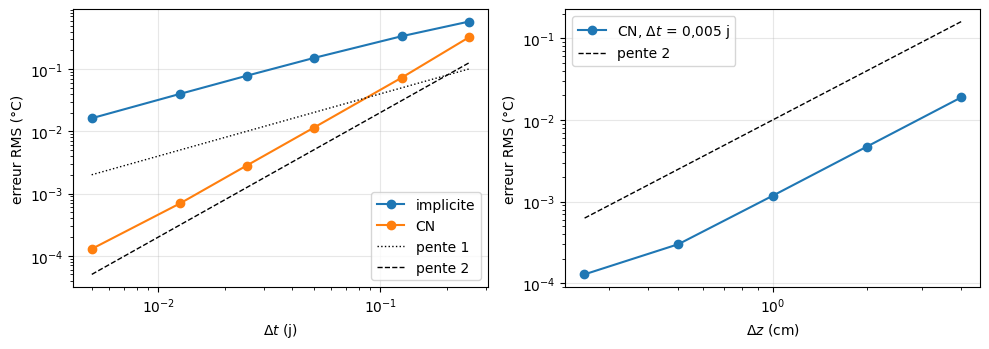

ordre observé en temps : implicite 0.92, CN 2.01 ; ordre en espace (CN) : 1.84
énergie stockée = -0.9754 MJ/m² ; flux de surface intégré = -0.9814 MJ/m² ; écart relatif = 0.61%
explicite, dt = 0.90 dt_lim = 0.00402 j : |T(10 cm)| max = 24.9 °C  ->  stable
explicite, dt = 1.03 dt_lim = 0.00460 j : |T(10 cm)| max = 1.59e+06 °C  ->  DIVERGE


In [4]:
def chaleur_1d(L, nz, dt, tmax, DT, theta_s, Tm=20.0, A0=10.0, T_init=None, z_obs=10.0):
    """Schéma theta (0 explicite, 1 implicite, 0.5 CN) pour dT/dt = DT d²T/dz², T(0,t) sinusoïdale, dT/dz = 0 au bas."""
    z = np.linspace(0, L, nz); dz = z[1] - z[0]; r = DT * dt / dz ** 2
    T = np.full(nz, Tm) if T_init is None else T_init(z)
    iobs = int(round(z_obs / dz))
    ab = np.zeros((3, nz))                      # matrice bande pour solve_banded (l=1, u=1)
    ab[1, :] = 1 + 2 * theta_s * r
    ab[0, 1:] = -theta_s * r                    # sur-diagonale
    ab[2, :-1] = -theta_s * r                   # sous-diagonale
    ab[1, 0] = 1.0; ab[0, 1] = 0.0              # Dirichlet en surface
    ab[2, -2] = -2 * theta_s * r                # gradient nul au bas (noeud fantôme T_{N+1} = T_{N-1})
    n = int(round(tmax / dt)); ts = np.arange(n + 1) * dt; Tobs = np.empty(n + 1); Tobs[0] = T[iobs]
    for k in range(1, n + 1):
        lap = np.zeros(nz)
        lap[1:-1] = T[2:] - 2 * T[1:-1] + T[:-2]
        lap[-1] = 2 * (T[-2] - T[-1])
        rhs = T + (1 - theta_s) * r * lap
        rhs[0] = Tm + A0 * np.sin(OM * ts[k])
        T = linalg.solve_banded((1, 1), ab, rhs)
        Tobs[k] = T[iobs]
    return z, T, ts, Tobs

def analytique(z, t, DT, Tm=20.0, A0=10.0):
    d = np.sqrt(2 * DT / OM)
    return Tm + A0 * np.exp(-z / d) * np.sin(OM * t - z / d)

DT = DT_l                                        # loam, theta = 0.243 (exercice 1)
L, tref = 100.0, 2.25
T0 = lambda z: analytique(z, 0.0, DT)

# 2. convergence en dt (dz = 0.25 cm) et en dz (CN, dt = 0.005 j)
zr = np.linspace(0, L, 401); m50 = zr <= 50
Tref = analytique(zr, tref, DT)
dts = [0.25, 0.125, 0.05, 0.025, 0.0125, 0.005]
err = {s: [] for s in ("implicite", "CN")}
for dt in dts:
    for s, th_s in [("implicite", 1.0), ("CN", 0.5)]:
        _, TT, _, _ = chaleur_1d(L, 401, dt, tref, DT, th_s, T_init=T0)
        err[s].append(np.sqrt(np.mean((TT[m50] - Tref[m50]) ** 2)))
dzs = [4.0, 2.0, 1.0, 0.5, 0.25]
err_dz = []
for dz in dzs:
    nz = int(L / dz) + 1; zz = np.linspace(0, L, nz)
    _, TT, _, _ = chaleur_1d(L, nz, 0.005, tref, DT, 0.5, T_init=T0)
    mm = zz <= 50
    err_dz.append(np.sqrt(np.mean((TT[mm] - analytique(zz[mm], tref, DT)) ** 2)))
fig, ax = plt.subplots(1, 2, figsize=(10, 3.6))
for s in err:
    ax[0].loglog(dts, err[s], "o-", label=s)
ax[0].loglog(dts, 0.4 * np.array(dts), "k:", lw=1, label="pente 1"); ax[0].loglog(dts, 2 * np.array(dts) ** 2, "k--", lw=1, label="pente 2")
ax[0].set_xlabel("$\\Delta t$ (j)"); ax[0].set_ylabel("erreur RMS (°C)"); ax[0].legend()
ax[1].loglog(dzs, err_dz, "o-", label="CN, $\\Delta t$ = 0,005 j"); ax[1].loglog(dzs, 0.01 * np.array(dzs) ** 2, "k--", lw=1, label="pente 2")
ax[1].set_xlabel("$\\Delta z$ (cm)"); ax[1].set_ylabel("erreur RMS (°C)"); ax[1].legend(); plt.tight_layout(); plt.show()
p_imp = np.polyfit(np.log(dts), np.log(err["implicite"]), 1)[0]; p_cn = np.polyfit(np.log(dts), np.log(err["CN"]), 1)[0]
p_dz = np.polyfit(np.log(dzs), np.log(err_dz), 1)[0]
print(f"ordre observé en temps : implicite {p_imp:.2f}, CN {p_cn:.2f} ; ordre en espace (CN) : {p_dz:.2f}")

# 3. bilan d'énergie (implicite, dt = 0.001 j, dz = 0.5 cm, 2 j, départ uniforme à 20 °C)
nz = 201; dt = 0.001
z, TT, ts, _ = chaleur_1d(L, nz, dt, 2.0, DT, 1.0)
dz = z[1] - z[0]
# tout en SI par unité de surface (J/m²) : longueurs cm -> m, temps j -> s
# énergie stockée : C * intégrale((T - T0) dz) ; flux en surface : -lambda dT/dz (différence décentrée d'ordre 2) intégré en temps
def flux_surface(T, dz):
    return -lam_l * (-3 * T[0] + 4 * T[1] - T[2]) / (2 * dz * 1e-2)      # W/m² (positif vers le bas)
T = np.full(nz, 20.0); E_in = 0.0; G_prev = flux_surface(T, dz)
r = DT * dt / dz ** 2
ab = np.zeros((3, nz)); ab[1, :] = 1 + 2 * r; ab[0, 1:] = -r; ab[2, :-1] = -r; ab[1, 0] = 1; ab[0, 1] = 0; ab[2, -2] = -2 * r
for k in range(1, int(round(2.0 / dt)) + 1):
    rhs = T.copy(); rhs[0] = 20 + 10 * np.sin(OM * k * dt)
    T = linalg.solve_banded((1, 1), ab, rhs)
    G = flux_surface(T, dz); E_in += 0.5 * (G + G_prev) * dt * S2J; G_prev = G
E_stock = C_l * np.trapezoid(T - 20.0, z * 1e-2)          # J/m²
print(f"énergie stockée = {E_stock/1e6:.4f} MJ/m² ; flux de surface intégré = {E_in/1e6:.4f} MJ/m² ; écart relatif = {abs(E_stock - E_in)/abs(E_in):.2%}")

# 4. explicite : stabilité
dz_e = 2.0; nz_e = int(L / dz_e) + 1; dt_lim = dz_e ** 2 / (2 * DT)
for fac in [0.9, 1.03]:
    _, _, ts_e, To = chaleur_1d(L, nz_e, fac * dt_lim, 2.0, DT, 0.0)
    print(f"explicite, dt = {fac:.2f} dt_lim = {fac*dt_lim:.5f} j : |T(10 cm)| max = {np.abs(To).max():.3g} °C  ->  {'DIVERGE' if np.abs(To).max() > 100 else 'stable'}")

**Commentaire (instructeur).** Les pentes observées (≈ 1 pour l'implicite, ≈ 2 pour Crank–Nicolson en temps et en espace) confirment l'analyse ; à $\Delta t$ égal, CN
est 10 à 100 fois plus précis. Le bilan d'énergie ferme à 0,6 % (l'écart vient de l'évaluation du gradient en surface au premier pas, où le saut de
température est brutal, et de l'intégration trapèze ; il décroît avec $\Delta t$) : c'est le test de conservation à faire pour tout solveur. L'explicite explose dès que $r$ dépasse 1/2 de 3 % : avec $\Delta z$ = 2 cm,
son pas limite (6 minutes) est 4 fois plus court que celui qu'exige la précision de l'onde journalière.

## Exercice 4 — HYDRUS-1D : conduction seule et conduction + convection  *(≈ 15 min)*

Projets `J09_chaleur_sans_convection` (loam, $h = -100$ cm, flux d'eau nul) et `J09_chaleur_avec_convection` (infiltration permanente
5 cm/j, $\theta = 0{,}405$) : surface à $20 \pm 10$ °C (période 1 j, maximum à 13 h), nœuds d'observation 5, 10, 20, 40 cm, 5 jours.

1. Lire `OBS_NODE.OUT` des deux projets (`read_obs_node`, variable `Temp`, nœuds 6, 11, 21, 41) et tracer $T(t)$ aux quatre profondeurs.
2. Sur le dernier jour ($t \ge 4$), ajuster $T = T_m + A\sin(\omega t + \varphi)$ à chaque profondeur ; régresser $\ln A$ et $\varphi$ sur $z$ :
   $d$ (amortissement) et longueur de phase, pour les deux projets.
3. Sans convection : comparer $d$ à $\sqrt{2D_T/\omega}$ avec $D_T$ du loam à $\theta = 0{,}243$ (exercice 1) et l'amplitude à chaque
   profondeur à $A_0 e^{-z/d}$.
4. Avec convection : calculer le nombre d'onde complexe $k = [-C_w q + \sqrt{(C_w q)^2 + 4 i\omega C\lambda}]/(2\lambda)$ (unités cm, j, g :
   $\lambda = \lambda_0(0{,}405) + \beta_T C_w q$, $\beta_T = 5$ cm, $q = 5$ cm/j) ; comparer $1/\mathrm{Re}(k)$ et $1/\mathrm{Im}(k)$ aux valeurs
   ajustées. Quelle part de la pénétration accrue vient de la convection, de la dispersion, du changement de $\theta$ ?

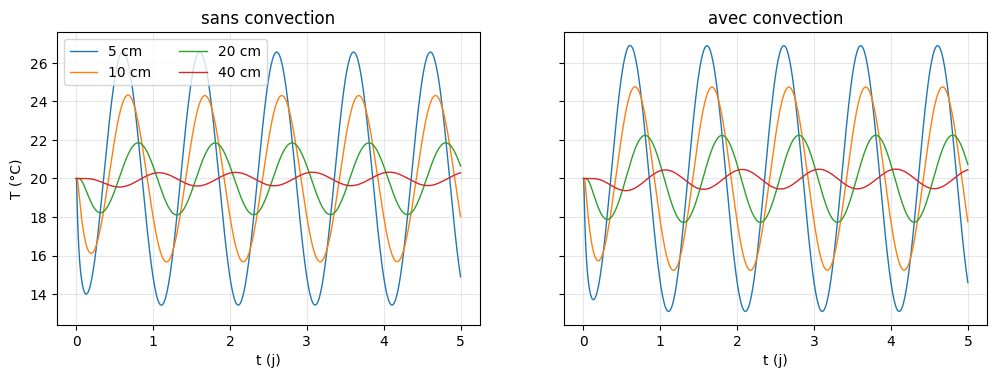

sans convection : A = [6.56 4.31 1.86 0.35] °C ; d (amplitude) = 11.92 cm ; longueur de phase = 11.96 cm
avec convection : A = [6.89 4.75 2.26 0.51] °C ; d (amplitude) = 13.43 cm ; longueur de phase = 12.21 cm
analytique (theta = 0,243) : d = 11.94 cm ; amplitudes A0 exp(-z/d) = [6.58 4.33 1.87 0.35]
retard (h) HYDRUS sans convection : [ 0.    1.6   4.79 11.18]  ; théorie : [ 0.    1.6   4.8  11.19]


,lam_W_m_K,C_MJ,v_T_cm_j,d_eff_cm,L_phase_cm
cas,,,,,
"sans convection (θ = 0,243)",1.095,2.110,0.000,11.945,11.945
"θ = 0,405, conduction seule",1.378,2.787,0.000,11.662,11.662
"θ = 0,405, convection sans dispersion",1.378,2.787,7.498,12.954,11.693
"θ = 0,405, convection + dispersion 5 cm",1.499,2.787,7.498,13.450,12.192
HYDRUS sans convection,NaN,NaN,NaN,11.921,11.961
HYDRUS avec convection,NaN,NaN,NaN,13.432,12.210


In [5]:
obs = {"sans": read_obs_node(f"{HYD}/J09_chaleur_sans_convection"), "avec": read_obs_node(f"{HYD}/J09_chaleur_avec_convection")}
noeuds = {6: 5, 11: 10, 21: 20, 41: 40}
zs = np.array(list(noeuds.values()))

# 1. tracés
fig, ax = plt.subplots(1, 2, figsize=(12, 3.8), sharey=True)
for a, (k, ob) in zip(ax, obs.items()):
    for nd, z in noeuds.items():
        a.plot(ob.index, ob[(nd, "Temp")], lw=1, label=f"{z} cm")
    a.set_title(f"{k} convection"); a.set_xlabel("t (j)")
ax[0].set_ylabel("T (°C)"); ax[0].legend(ncol=2); plt.show()

# 2. amplitude et phase sur le dernier jour
def amp_phase(df, nd, t0=4.0):
    s = df[(nd, "Temp")]; s = s[s.index >= t0]
    p, _ = optimize.curve_fit(lambda t, Tm, A, phi: Tm + A * np.sin(OM * t + phi), s.index.to_numpy(), s.to_numpy(), p0=[20, 5, 0])
    A, phi = p[1], p[2]
    if A < 0: A, phi = -A, phi + np.pi
    return A, phi

res = {}
for k, ob in obs.items():
    A = np.array([amp_phase(ob, nd)[0] for nd in noeuds]); phi = np.unwrap(np.array([amp_phase(ob, nd)[1] for nd in noeuds]))
    sA = np.polyfit(zs, np.log(A), 1)[0]; sP = np.polyfit(zs, phi, 1)[0]
    res[k] = dict(A=A, phi=phi, d_amp=-1 / sA, d_phase=-1 / sP)
    print(f"{k} convection : A = {np.round(A, 2)} °C ; d (amplitude) = {-1/sA:.2f} cm ; longueur de phase = {-1/sP:.2f} cm")

# 3. sans convection vs analytique
d_th = np.sqrt(2 * DT_l / OM)
print(f"analytique (theta = 0,243) : d = {d_th:.2f} cm ; amplitudes A0 exp(-z/d) = {np.round(10 * np.exp(-zs / d_th), 2)}")
print("retard (h) HYDRUS sans convection :", np.round((res['sans']['phi'][0] - res['sans']['phi']) / OM * 24, 2), " ; théorie :", np.round((zs - 5) / d_th / OM * 24, 2))

# 4. avec convection : nombre d'onde complexe (unités g, cm, j)
f_lam = 1e3 * 1e2 * S2J ** 3; f_C = 1e3 * 1e-2 * S2J ** 2
Cw_h = Cw * f_C
def k_complexe(theta, q, beta_T):
    lam = lam_CH(theta, "loam") * f_lam + beta_T * Cw_h * q
    C = C_vol(theta, "loam") * f_C
    return (-Cw_h * q + np.sqrt((Cw_h * q) ** 2 + 4j * OM * C * lam)) / (2 * lam), lam, C
rows = []
for lab, th, q, bT in [("sans convection (θ = 0,243)", 0.243, 0.0, 0.0), ("θ = 0,405, conduction seule", 0.405, 0.0, 0.0),
                       ("θ = 0,405, convection sans dispersion", 0.405, 5.0, 0.0), ("θ = 0,405, convection + dispersion 5 cm", 0.405, 5.0, 5.0)]:
    kk, lam, C = k_complexe(th, q, bT)
    rows.append(dict(cas=lab, lam_W_m_K=lam / f_lam, C_MJ=C / f_C / 1e6, v_T_cm_j=Cw_h * q / C, d_eff_cm=1 / kk.real, L_phase_cm=1 / kk.imag))
tab = pd.DataFrame(rows).set_index("cas")
tab.loc["HYDRUS sans convection", ["d_eff_cm", "L_phase_cm"]] = [res["sans"]["d_amp"], res["sans"]["d_phase"]]
tab.loc["HYDRUS avec convection", ["d_eff_cm", "L_phase_cm"]] = [res["avec"]["d_amp"], res["avec"]["d_phase"]]
display(tab.round(3))

**Commentaire (instructeur).** Sans convection, HYDRUS reproduit exactement l'onde analytique : $d = 11{,}9$ cm par l'amplitude comme par la phase, amplitudes 6,56 / 4,31 /
1,86 / 0,35 °C. Avec l'infiltration de 5 cm/j, $d_{eff}$ passe à 13,4 cm alors que la longueur de phase reste ≈ 12,2 cm : la convection
transporte l'onde vers le bas ($v_T = 7{,}5$ cm/j) sans modifier son déphasage. La solution à nombre d'onde complexe (13,45 et 12,2 cm)
reproduit HYDRUS ; la conduction seule à $\theta = 0{,}405$ donnerait 11,7 cm (la hausse de $C$ l'emporte sur celle de $\lambda$),
la convection apporte +1,3 cm et la dispersion thermique +0,5 cm.

## Exercice 5 — Bonus — flux de chaleur en surface et énergie stockée  *(≈ facultatif)*

À partir des profils `NOD_INF.OUT` du projet sans convection (toutes les 3 h), calculer le flux de chaleur en surface
$G(0,t) = -\lambda\,\partial T/\partial z|_0$ (W/m², différence décentrée d'ordre 2, $\lambda = 1{,}095$ W m$^{-1}$ K$^{-1}$) et le comparer à
$G = \sqrt2\lambda A_0/d\,\sin(\omega t - 7\pi/12 + \pi/4)$. En déduire l'énergie stockée entre le minimum et le maximum de $T_s$ (MJ/m²).

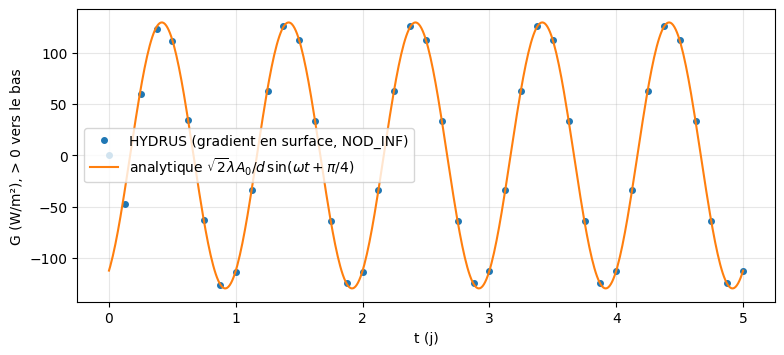

amplitude du flux : 130 W/m² (HYDRUS : 126) ; énergie stockée par demi-période : 3.56 MJ/m²


In [6]:
nod = read_nod_inf(f"{HYD}/J09_chaleur_sans_convection")
times = np.array(sorted(nod)); G = []
for tt in times:
    T = nod[tt]["Temp"].to_numpy(); dz = abs(nod[tt]["Depth"].iloc[1] - nod[tt]["Depth"].iloc[0]) * 1e-2
    G.append(-lam_l * (-3 * T[0] + 4 * T[1] - T[2]) / (2 * dz))
G = np.array(G)
tt = np.linspace(0, 5, 500)
G_th = np.sqrt(2) * lam_l * 10 / (d_l * 1e-2) * np.sin(OM * tt - 7 * np.pi / 12 + np.pi / 4)
fig, ax = plt.subplots(figsize=(9, 3.8))
ax.plot(times, G, "o", ms=4, label="HYDRUS (gradient en surface, NOD_INF)"); ax.plot(tt, G_th, label="analytique $\sqrt{2}\lambda A_0/d\,\sin(\omega t + \pi/4)$")
ax.set_xlabel("t (j)"); ax.set_ylabel("G (W/m²), > 0 vers le bas"); ax.legend(); plt.show()
Gmax = np.sqrt(2) * lam_l * 10 / (d_l * 1e-2)
E_demi = 2 * Gmax / OM * S2J / 1e6      # intégrale de G sur sa demi-période positive : 2 Gmax / omega
print(f"amplitude du flux : {Gmax:.0f} W/m² (HYDRUS : {np.abs(G[times >= 4]).max():.0f}) ; énergie stockée par demi-période : {E_demi:.2f} MJ/m²")

**Commentaire (instructeur).** Le flux en surface culmine à ≈ 130 W/m² et précède la température de 3 h ; l'énergie stockée puis restituée chaque jour (≈ 3,6 MJ/m²)
équivaut à l'évaporation de 1,5 mm d'eau. Le gradient HYDRUS au premier nœud est légèrement sous-estimé (différence finie sur 1 cm
pour une onde de 12 cm) : raffiner le maillage près de la surface si le flux importe.

## Pour aller plus loin

* Onde annuelle + onde journalière superposées : simuler 2 ans avec le schéma implicite et retrouver le retard saisonnier à 1 m.
* Coupler $\lambda(\theta(z,t))$ et $C(\theta(z,t))$ au profil d'humidité du J8 (redistribution) dans le solveur de l'exercice 3.
* Estimer $D_T$ par HYDRUS inverse (J10) à partir des séries de l'exercice 2.